In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline

# LOAD DATA

df = pd.read_csv('dataset_mahasiswa_news.csv')
df.columns = df.columns.str.strip()

df_plot = df.copy()

In [ ]:
# PREPROCESSING UNTUK MODEL

df_model = df.copy()

drop_cols = ['lama_studi', 'lulus_umur']
df_model  = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

def encode_target(val):
    val = str(val).strip().lower()
    if val in ['tepat waktu','1','ya','yes']:            return 1
    elif val in ['tidak tepat waktu','0','tidak','no']:  return 0
    return np.nan

df_model['lulus_tepat_waktu'] = df_model['lulus_tepat_waktu'].apply(encode_target)
df_model = df_model.dropna(subset=['lulus_tepat_waktu'])
df_model['lulus_tepat_waktu'] = df_model['lulus_tepat_waktu'].astype(int)

le = LabelEncoder()
for col in ['prodi', 'jenis_kelamin', 'status_pegawai']:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

feature_cols = [c for c in [
    'prodi','jenis_kelamin','status_pegawai',
    'ips_1','ips_2','ips_3','ips_4','ips_5','ips_6','ips_7','ips_8',
    'IPK','sks_mk','umur'
] if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model['lulus_tepat_waktu'].copy()
X = X.fillna(X.mean(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# GRID SEARCH

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("GRID SEARCH CV – Mencari Hyperparameter Terbaik")

# 1. Logistic Regression
print("\n[1/3] GridSearch: Logistic Regression...")
param_lr = {
    'C':        [0.01, 0.1, 1.0, 10, 100],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear', 'saga'],
    'max_iter': [1000]
}
gs_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_lr, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_s, y_train)
best_lr = gs_lr.best_estimator_
print(f"  Best params : {gs_lr.best_params_}")
print(f"  Best CV AUC : {gs_lr.best_score_:.4f}")

# 2. Decision Tree
print("\n[2/3] GridSearch: Decision Tree...")
param_dt = {
    'max_depth':        [4, 6, 8, 10, None],
    'min_samples_split':[10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion':        ['gini', 'entropy']
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_dt, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_dt.fit(X_train, y_train)
best_dt = gs_dt.best_estimator_
print(f"  Best params : {gs_dt.best_params_}")
print(f"  Best CV AUC : {gs_dt.best_score_:.4f}")

# 3. Random Forest
print("\n[3/3] GridSearch: Random Forest...")
param_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [6, 8, 10, None],
    'min_samples_split':[10, 20],
    'min_samples_leaf': [5, 10],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_rf, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_
print(f"  Best params : {gs_rf.best_params_}")
print(f"  Best CV AUC : {gs_rf.best_score_:.4f}")

GRID SEARCH CV – Mencari Hyperparameter Terbaik

[1/3] GridSearch: Logistic Regression...
  Best params : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV AUC : 0.8024

[2/3] GridSearch: Decision Tree...
  Best params : {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 50}
  Best CV AUC : 0.7700

[3/3] GridSearch: Random Forest...
  Best params : {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200}
  Best CV AUC : 0.8384


In [ ]:
# 3. Random Forest
print("\n[3/3] GridSearch: Random Forest...")
param_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_rf, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_
print(f"  Best params : {gs_rf.best_params_}")
print(f"  Best CV AUC : {gs_rf.best_score_:.4f}")


[3/3] GridSearch: Random Forest...
  Best params : {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
  Best CV AUC : 0.8446


In [ ]:
# EVALUASI MODEL

print("EVALUASI MODEL")

y_pred_lr = best_lr.predict(X_test_s);  y_prob_lr = best_lr.predict_proba(X_test_s)[:,1]
y_pred_dt = best_dt.predict(X_test);    y_prob_dt = best_dt.predict_proba(X_test)[:,1]
y_pred_rf = best_rf.predict(X_test);    y_prob_rf = best_rf.predict_proba(X_test)[:,1]

def get_metrics(yt, yp, yprob):
    return [accuracy_score(yt,yp),
            precision_score(yt,yp,zero_division=0),
            recall_score(yt,yp),
            f1_score(yt,yp),
            roc_auc_score(yt,yprob)]

m_lr = get_metrics(y_test, y_pred_lr, y_prob_lr)
m_dt = get_metrics(y_test, y_pred_dt, y_prob_dt)
m_rf = get_metrics(y_test, y_pred_rf, y_prob_rf)

print(f"\nLogistic Regression: Acc={m_lr[0]:.4f} | Prec={m_lr[1]:.4f} | Rec={m_lr[2]:.4f} | F1={m_lr[3]:.4f} | AUC={m_lr[4]:.4f}")
print(f"Decision Tree      : Acc={m_dt[0]:.4f} | Prec={m_dt[1]:.4f} | Rec={m_dt[2]:.4f} | F1={m_dt[3]:.4f} | AUC={m_dt[4]:.4f}")
print(f"Random Forest      : Acc={m_rf[0]:.4f} | Prec={m_rf[1]:.4f} | Rec={m_rf[2]:.4f} | F1={m_rf[3]:.4f} | AUC={m_rf[4]:.4f}")


EVALUASI MODEL

Logistic Regression: Acc=0.7559 | Prec=0.9864 | Rec=0.7564 | F1=0.8562 | AUC=0.8345
Decision Tree      : Acc=0.7982 | Prec=0.9871 | Rec=0.8005 | F1=0.8840 | AUC=0.8090
Random Forest      : Acc=0.9599 | Prec=0.9683 | Rec=0.9907 | F1=0.9794 | AUC=0.8609


In [ ]:
print("\n OVERFITTING CHECK : ")

# Logistic Regression
print("LR Train:", best_lr.score(X_train_s, y_train))
print("LR Test :", best_lr.score(X_test_s, y_test))

# Decision Tree
print("DT Train:", best_dt.score(X_train, y_train))
print("DT Test :", best_dt.score(X_test, y_test))

# Random Forest
print("RF Train:", best_rf.score(X_train, y_train))
print("RF Test :", best_rf.score(X_test, y_test))


 OVERFITTING CHECK : 
LR Train: 0.747350808700502
LR Test : 0.7558528428093646
DT Train: 0.7916899051868377
DT Test : 0.798216276477146
RF Train: 0.9933073061907418
RF Test : 0.959866220735786


In [ ]:

# Feature importance

name_map = {
    'ips_1':'IPS 1','ips_2':'IPS 2','ips_3':'IPS 3','ips_4':'IPS 4',
    'ips_5':'IPS 5','ips_6':'IPS 6', 'IPK':'IPS Kumulatif','umur':'Usia Masuk','prodi':'Prodi',
    'jenis_kelamin':'Jenis Kelamin','status_pegawai':'Status Bekerja'
}
fi_scores  = best_rf.feature_importances_
fi_display = [name_map.get(c, c) for c in feature_cols]

# HELPER
def save(fname):
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

ips_cols = ['ips_1','ips_2','ips_3','ips_4','ips_5','ips_6']
BIRU     = '#2E75B6'
ORANGE   = '#ED7D31'
tepat_df = df_plot[df_plot['lulus_tepat_waktu'] == 'Tepat waktu']
tidak_df = df_plot[df_plot['lulus_tepat_waktu'] == 'Tidak tepat waktu']

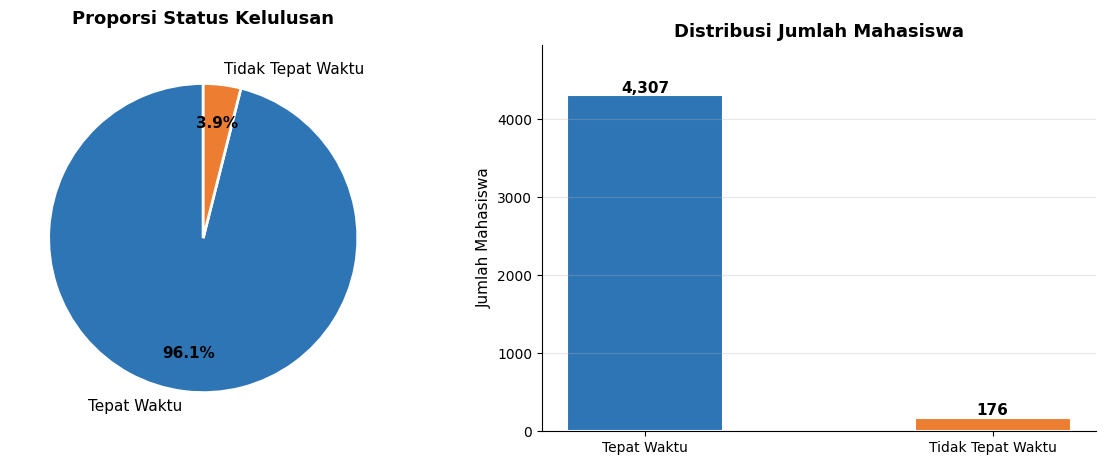

In [ ]:
# FIG 4.1 – Distribusi Kelas

tepat = len(tepat_df)
tidak = len(tidak_df)
labels = ['Tepat Waktu','Tidak Tepat Waktu']
sizes  = [tepat, tidak]
colors = [BIRU, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(12,5))
_, _, autotexts = axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize':11}, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Proporsi Status Kelulusan', fontsize=13, fontweight='bold', pad=15)
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.45)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Jumlah Mahasiswa', fontsize=11)
axes[1].set_title('Distribusi Jumlah Mahasiswa', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(sizes)*1.15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

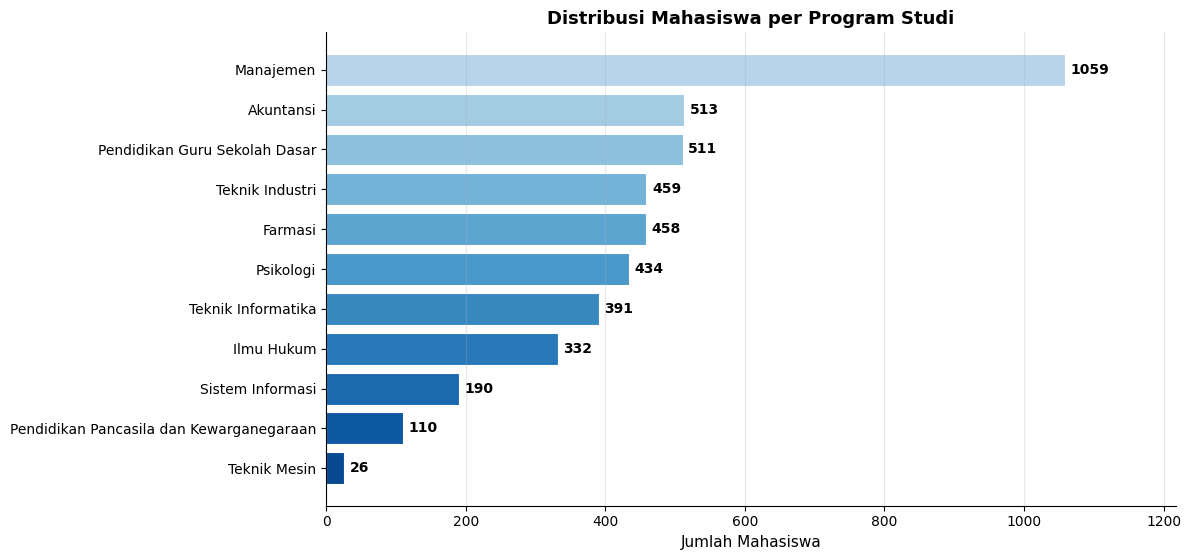

In [ ]:
# FIG 4.2 – Distribusi Prodi

prodi_count = df_plot['prodi'].value_counts()
colors_p    = plt.cm.Blues(np.linspace(0.9, 0.3, len(prodi_count)))
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.barh(prodi_count.index[::-1], prodi_count.values[::-1],
               color=colors_p, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, prodi_count.values[::-1]):
    ax.text(val+8, bar.get_y()+bar.get_height()/2, f'{val}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Jumlah Mahasiswa', fontsize=11)
ax.set_title('Distribusi Mahasiswa per Program Studi', fontsize=13, fontweight='bold')
ax.set_xlim(0, prodi_count.max()*1.15)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

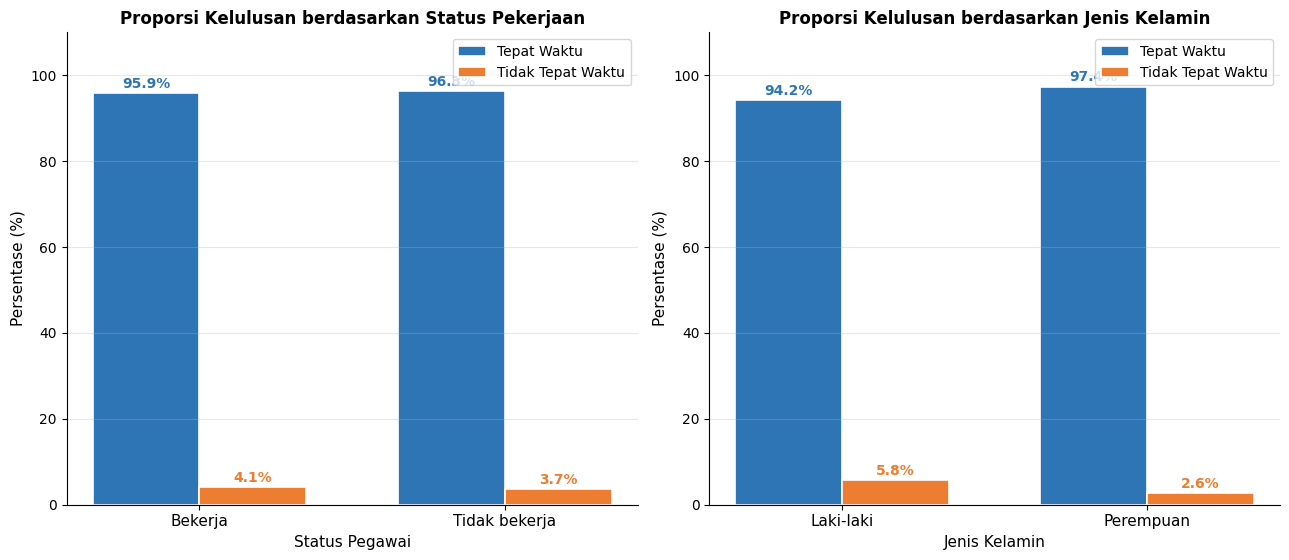

In [ ]:
# FIG 4.3 – Status Pekerjaan & Jenis Kelamin

cols_order = ['Tepat waktu','Tidak tepat waktu']
status_pct = pd.crosstab(df_plot['status_pegawai'], df_plot['lulus_tepat_waktu'],
                          normalize='index') * 100
status_pct = status_pct.reindex(columns=cols_order, fill_value=0)
gender_pct = pd.crosstab(df_plot['jenis_kelamin'], df_plot['lulus_tepat_waktu'],
                          normalize='index') * 100
gender_pct = gender_pct.reindex(columns=cols_order, fill_value=0)

W = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13,6))
def plot_grouped(ax, data, xlabel, title):
    x2 = np.arange(len(data.index))
    b1 = ax.bar(x2-W/2, data['Tepat waktu'].values, W,
                label='Tepat Waktu', color=BIRU, edgecolor='white', linewidth=1.2)
    b2 = ax.bar(x2+W/2, data['Tidak tepat waktu'].values, W,
                label='Tidak Tepat Waktu', color=ORANGE, edgecolor='white', linewidth=1.2)
    for bar in b1:
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%',
                          ha='center', va='bottom', fontsize=10, fontweight='bold', color=BIRU)
    for bar in b2:
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%',
                          ha='center', va='bottom', fontsize=10, fontweight='bold', color=ORANGE)
    ax.set_xticks(x2); ax.set_xticklabels(data.index, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('Persentase (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10); ax.set_ylim(0,110)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plot_grouped(axes[0], status_pct, 'Status Pegawai',
             'Proporsi Kelulusan berdasarkan Status Pekerjaan')
plot_grouped(axes[1], gender_pct, 'Jenis Kelamin',
             'Proporsi Kelulusan berdasarkan Jenis Kelamin')
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

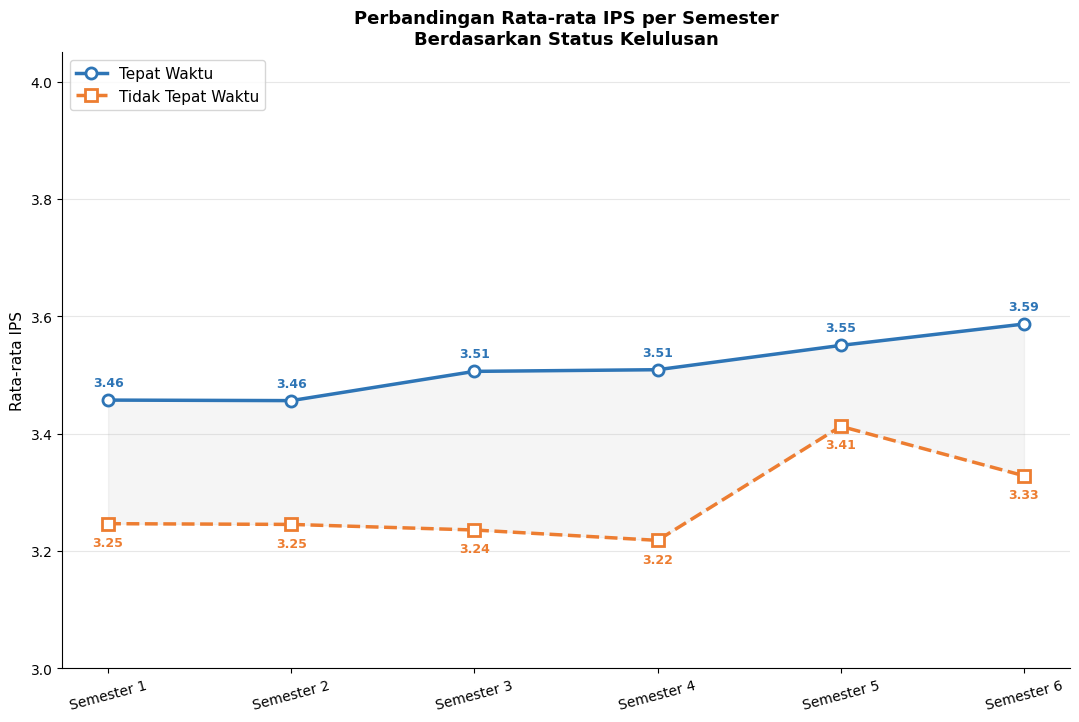

In [ ]:
# FIG 4.4 – Rata-rata IPS per Semester

ips_t  = tepat_df[ips_cols].mean().values
ips_tt = tidak_df[ips_cols].mean().values
sem    = [f'Semester {i}' for i in range(1,9)]
x      = np.arange(len(sem))

x = np.arange(len(ips_t))
sem = [f'Semester {i}' for i in range(1, len(ips_t)+1)]

fig, ax = plt.subplots(figsize=(13,8))
ax.fill_between(x, ips_t, ips_tt, alpha=0.08, color='gray')
ax.plot(x, ips_t,  'o-',  color=BIRU,   lw=2.5, ms=8, label='Tepat Waktu',
        markerfacecolor='white', markeredgewidth=2)
ax.plot(x, ips_tt, 's--', color=ORANGE, lw=2.5, ms=8, label='Tidak Tepat Waktu',
        markerfacecolor='white', markeredgewidth=2)
for i,(t,tt) in enumerate(zip(ips_t, ips_tt)):
    ax.annotate(f'{t:.2f}',  (x[i],t),  textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=9, fontweight='bold', color=BIRU)
    ax.annotate(f'{tt:.2f}', (x[i],tt), textcoords='offset points', xytext=(0,-16),
                ha='center', fontsize=9, fontweight='bold', color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(sem, rotation=15, fontsize=10)
ax.set_ylabel('Rata-rata IPS', fontsize=11)
ax.set_title('Perbandingan Rata-rata IPS per Semester\nBerdasarkan Status Kelulusan',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left'); ax.set_ylim(3.0, 4.05)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

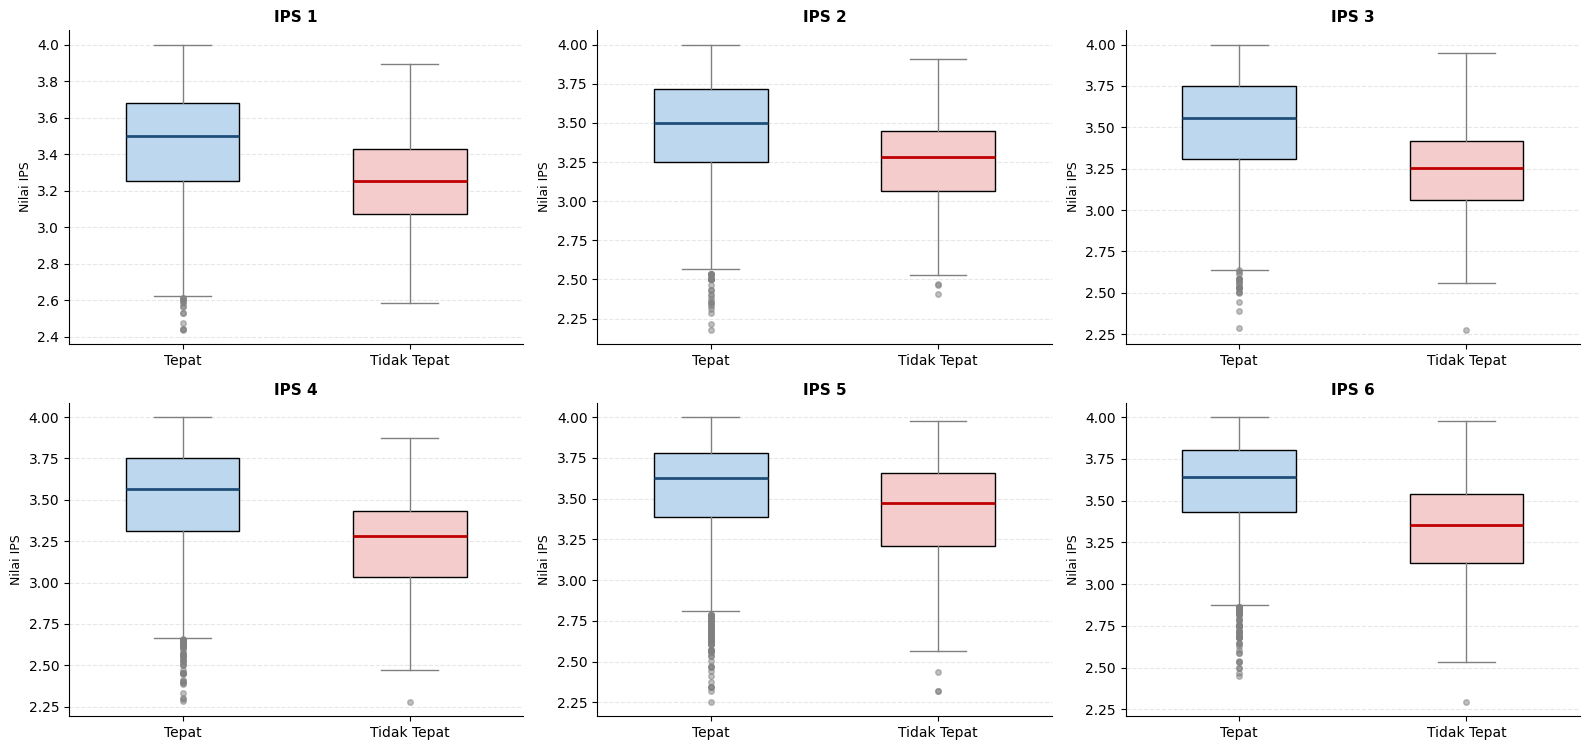

In [ ]:
# FIG 4.5 – Boxplot IPS

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()
for i, col in enumerate(ips_cols):
    ax  = axes[i]
    d_t = tepat_df[col].dropna().values
    d_tt= tidak_df[col].dropna().values
    bp  = ax.boxplot([d_t, d_tt], tick_labels=['Tepat','Tidak Tepat'],
                     patch_artist=True, notch=False, widths=0.5,
                     flierprops=dict(marker='o', markersize=4, linestyle='none',
                                    markerfacecolor='gray', markeredgecolor='gray', alpha=0.5))
    bp['boxes'][0].set_facecolor('#BDD7EE')
    bp['boxes'][1].set_facecolor('#F4CCCC')
    bp['medians'][0].set_color('#1F4E79'); bp['medians'][0].set_linewidth(2)
    bp['medians'][1].set_color('#C00000'); bp['medians'][1].set_linewidth(2)
    for j in range(2):
        bp['whiskers'][j*2].set_color('gray');   bp['whiskers'][j*2+1].set_color('gray')
        bp['caps'][j*2].set_color('gray');       bp['caps'][j*2+1].set_color('gray')
    ax.set_title(f'IPS {i+1}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Nilai IPS', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

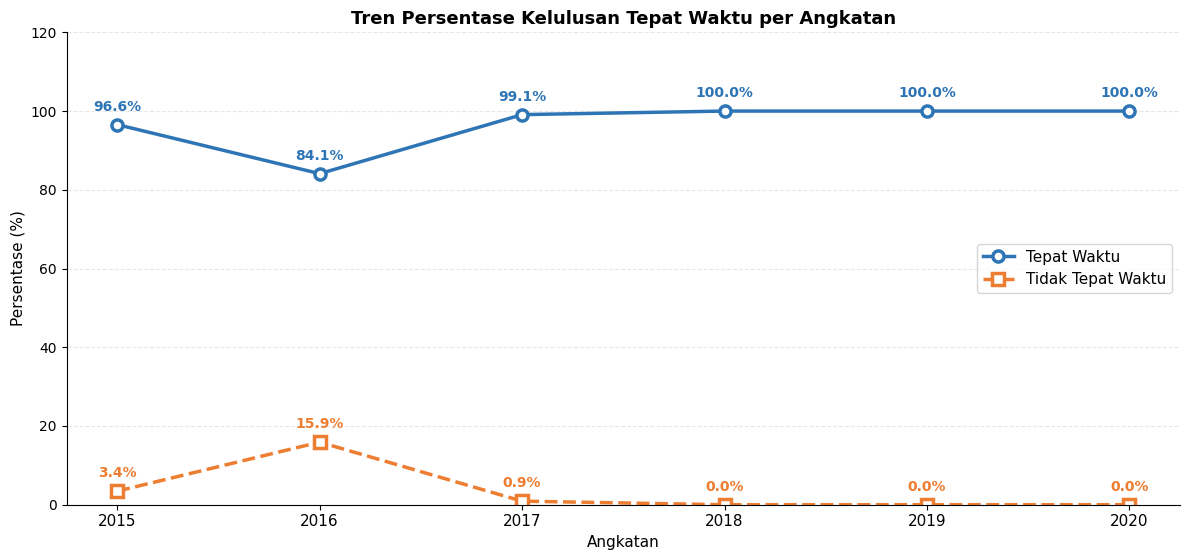

In [ ]:
# FIG 4.6 – Tren Angkatan

angk_grp  = pd.crosstab(df_plot['angkatan'], df_plot['lulus_tepat_waktu'])
pct       = angk_grp.div(angk_grp.sum(axis=1), axis=0) * 100
tepat_pct = pct['Tepat waktu'].values
tidak_pct = pct['Tidak tepat waktu'].values
angkatan  = pct.index.astype(int).tolist()
x3        = np.arange(len(angkatan))

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(x3, tepat_pct, 'o-',  color=BIRU,   lw=2.5, ms=8, label='Tepat Waktu',
        markerfacecolor='white', markeredgewidth=2.5)
ax.plot(x3, tidak_pct, 's--', color=ORANGE, lw=2.5, ms=8, label='Tidak Tepat Waktu',
        markerfacecolor='white', markeredgewidth=2.5)
for i,(t,tt) in enumerate(zip(tepat_pct, tidak_pct)):
    ax.annotate(f'{t:.1f}%',  (x3[i],t),  textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=10, fontweight='bold', color=BIRU)
    ax.annotate(f'{tt:.1f}%', (x3[i],tt), textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=10, fontweight='bold', color=ORANGE)
ax.set_xticks(x3); ax.set_xticklabels(angkatan, fontsize=11)
ax.set_xlabel('Angkatan', fontsize=11); ax.set_ylabel('Persentase (%)', fontsize=11)
ax.set_title('Tren Persentase Kelulusan Tepat Waktu per Angkatan',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='center right'); ax.set_ylim(0,120)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

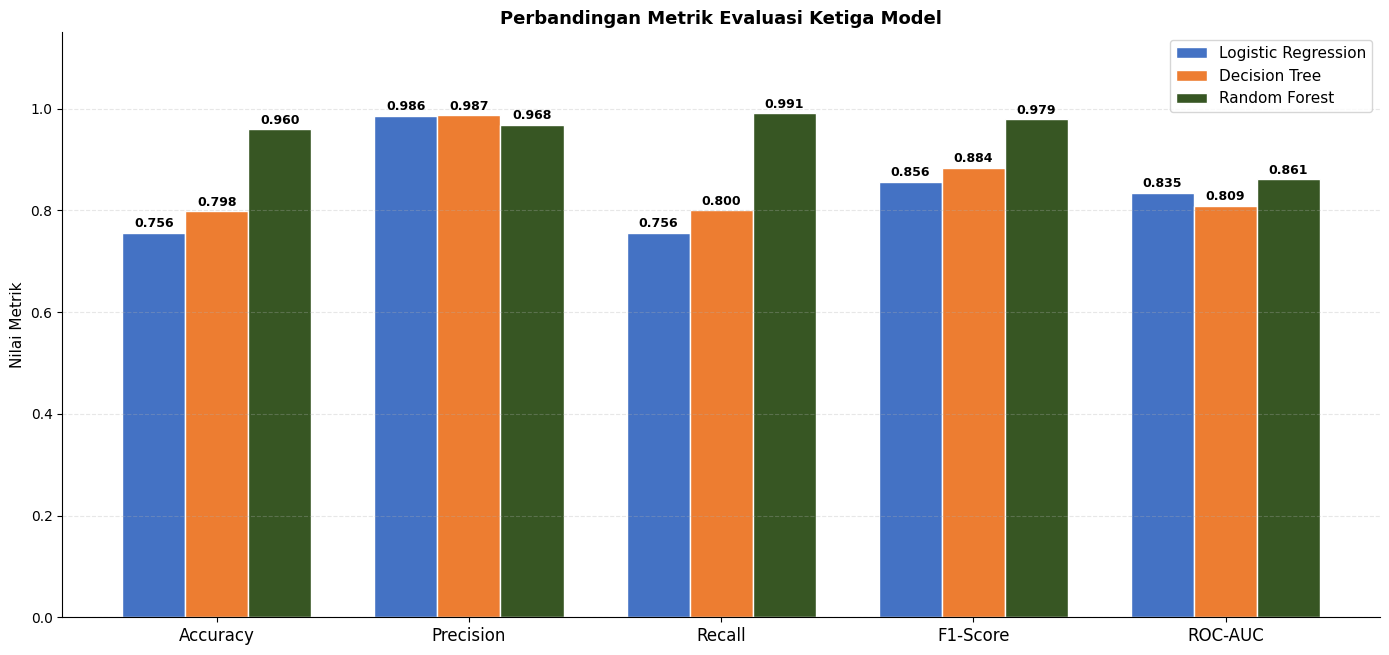

In [ ]:
# FIG 4.7 – Perbandingan Metrik

metric_names = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x2 = np.arange(len(metric_names)); W2 = 0.25
fig, ax = plt.subplots(figsize=(14,7))
b1 = ax.bar(x2-W2, m_lr, W2, label='Logistic Regression', color='#4472C4', edgecolor='white')
b2 = ax.bar(x2,    m_dt, W2, label='Decision Tree',        color=ORANGE,   edgecolor='white')
b3 = ax.bar(x2+W2, m_rf, W2, label='Random Forest',        color='#375623',edgecolor='white')
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Nilai Metrik', fontsize=11)
ax.set_title('Perbandingan Metrik Evaluasi Ketiga Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right'); ax.set_ylim(0,1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


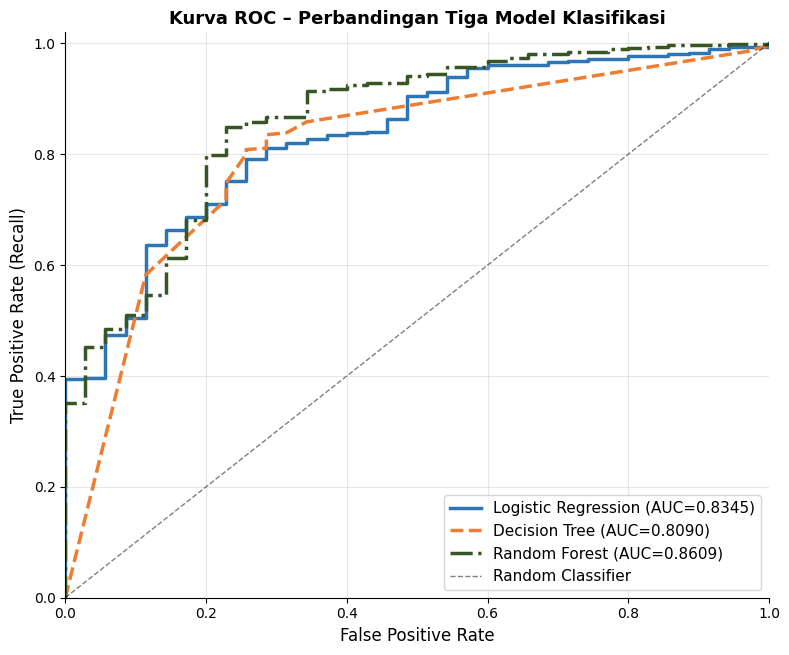

In [ ]:
# FIG 4.8 – Kurva ROC

fig, ax = plt.subplots(figsize=(8,7))
fpr_lr,tpr_lr,_ = roc_curve(y_test, y_prob_lr)
fpr_dt,tpr_dt,_ = roc_curve(y_test, y_prob_dt)
fpr_rf,tpr_rf,_ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_lr, tpr_lr, color=BIRU,     lw=2.5,
        label=f'Logistic Regression (AUC={m_lr[4]:.4f})')
ax.plot(fpr_dt, tpr_dt, color=ORANGE,   lw=2.5, ls='--',
        label=f'Decision Tree (AUC={m_dt[4]:.4f})')
ax.plot(fpr_rf, tpr_rf, color='#375623',lw=2.5, ls='-.',
        label=f'Random Forest (AUC={m_rf[4]:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Kurva ROC – Perbandingan Tiga Model Klasifikasi',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


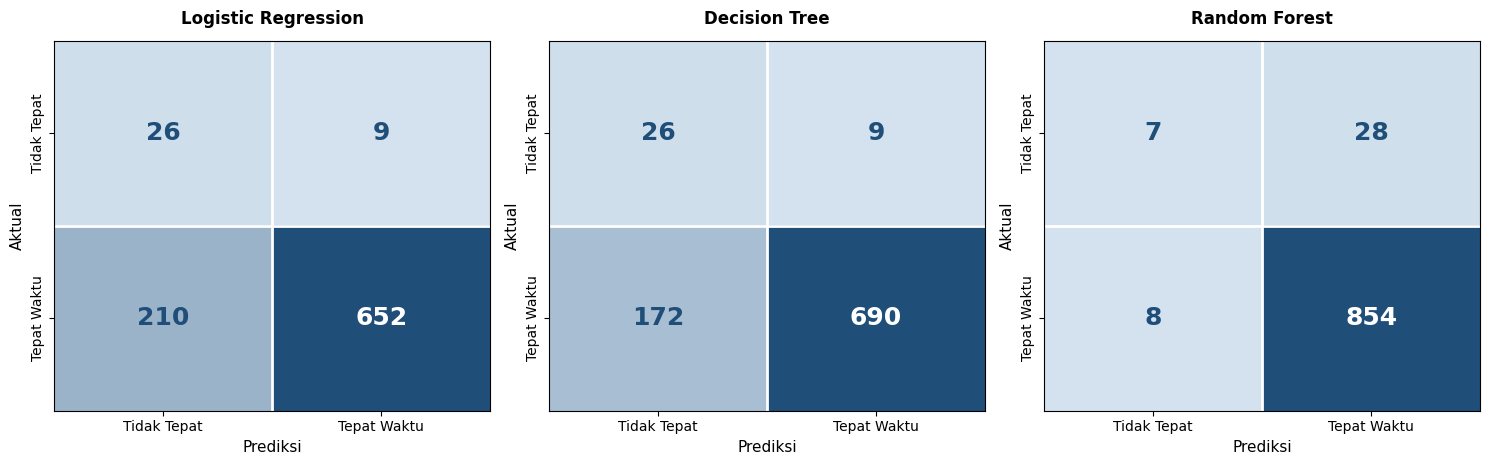

In [ ]:
# FIG 4.9 – Confusion Matrix

cms_list    = [confusion_matrix(y_test, y_pred_lr),
               confusion_matrix(y_test, y_pred_dt),
               confusion_matrix(y_test, y_pred_rf)]
model_names = ['Logistic Regression','Decision Tree','Random Forest']
cmap_cm     = mcolors.LinearSegmentedColormap.from_list('bc',['#D6E4F0','#1F4E79'])
tick_lbl    = ['Tidak Tepat','Tepat Waktu']

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, cm, title in zip(axes, cms_list, model_names):
    norm = cm / cm.max()
    ax.imshow(norm, cmap=cmap_cm, vmin=0, vmax=1, aspect='auto')
    for r in range(2):
        for c in range(2):
            col_txt = 'white' if norm[r,c] > 0.5 else '#1F4E79'
            ax.text(c, r, str(cm[r,c]), ha='center', va='center',
                    fontsize=18, fontweight='bold', color=col_txt)
    ax.set_xticks([0,1]); ax.set_xticklabels(tick_lbl, fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Tidak Tepat','Tepat Waktu'],
                                              fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Prediksi', fontsize=11); ax.set_ylabel('Aktual', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xticks([0.5], minor=True); ax.set_yticks([0.5], minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='minor', bottom=False, left=False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

In [ ]:
# FIG 4.10 – Feature Importance

sorted_idx  = np.argsort(fi_scores)
fi_sorted   = fi_scores[sorted_idx]
name_sorted = [fi_display[i] for i in sorted_idx]
cmap_fi     = mcolors.LinearSegmentedColormap.from_list('bg',['#BDD7EE','#1F4E79'])
norm_fi     = (fi_sorted-fi_sorted.min())/(fi_sorted.max()-fi_sorted.min())
colors_fi   = [cmap_fi(v) for v in norm_fi]

fig, ax = plt.subplots(figsize=(11, max(6, len(fi_sorted)*0.55)))
bars = ax.barh(name_sorted, fi_sorted, color=colors_fi,
               edgecolor='white', linewidth=0.6, height=0.7)
for bar, val in zip(bars, fi_sorted):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9, fontweight='bold', color='#1F4E79')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Feature Importance – Random Forest ',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, fi_sorted.max()*1.18)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

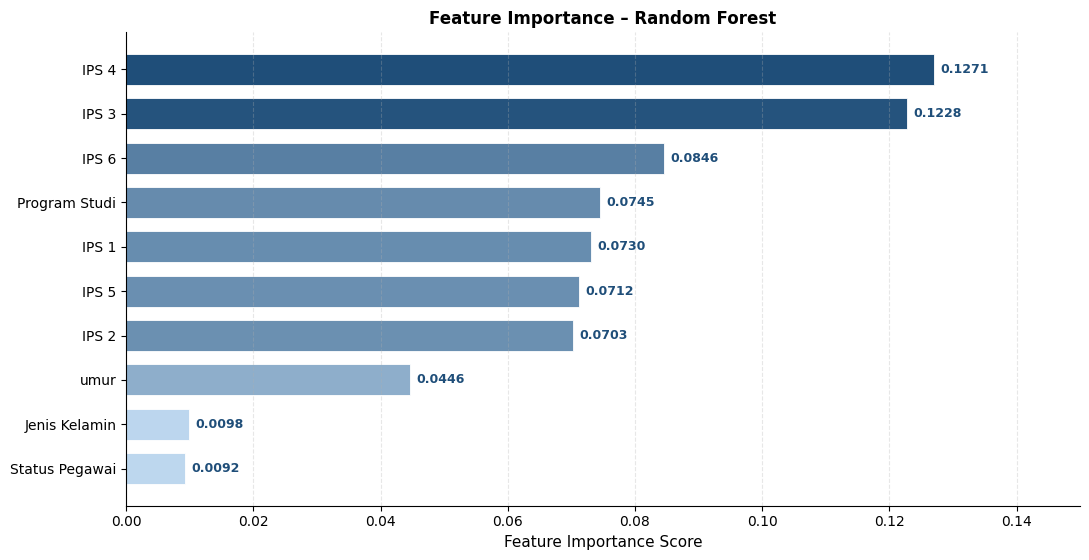

In [ ]:
# FIG 4.10 – Feature Importance

# Mapping nama (hanya feature yang mau ditampilkan)
name_map = {
    'ips_1':'IPS 1','ips_2':'IPS 2','ips_3':'IPS 3','ips_4':'IPS 4',
    'ips_5':'IPS 5','ips_6':'IPS 6',
    'prodi':'Program Studi',
    'jenis_kelamin':'Jenis Kelamin',
    'status_pegawai':'Status Pegawai', 'umur':'umur'
}

# Ambil feature importance dari model terbaik
fi_scores = best_rf.feature_importances_
fi_display = feature_cols

# Filter hanya feature yang ada di name_map
filtered = [(f, s) for f, s in zip(fi_display, fi_scores) if f in name_map]

fi_display = [name_map[f] for f, s in filtered]
fi_scores  = [s for f, s in filtered]

# Sorting
sorted_idx  = np.argsort(fi_scores)
fi_sorted   = np.array(fi_scores)[sorted_idx]
name_sorted = [fi_display[i] for i in sorted_idx]

# Warna gradient
cmap_fi   = mcolors.LinearSegmentedColormap.from_list('bg',['#BDD7EE','#1F4E79'])
norm_fi   = (fi_sorted-fi_sorted.min())/(fi_sorted.max()-fi_sorted.min())
colors_fi = [cmap_fi(v) for v in norm_fi]

# Plot
fig, ax = plt.subplots(figsize=(11, max(6, len(fi_sorted)*0.55)))
bars = ax.barh(name_sorted, fi_sorted, color=colors_fi,
               edgecolor='white', linewidth=0.6, height=0.7)

# Label angka
for bar, val in zip(bars, fi_sorted):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9, fontweight='bold', color='#1F4E79')

# Styling
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Feature Importance – Random Forest',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, fi_sorted.max()*1.18)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

In [ ]:
# BEST PARAMS

print("RINGKASAN HYPERPARAMETER TERBAIK")
print(f"\nLogistic Regression : {gs_lr.best_params_}  | CV AUC = {gs_lr.best_score_:.4f}")
print(f"Decision Tree       : {gs_dt.best_params_}  | CV AUC = {gs_dt.best_score_:.4f}")
print(f"Random Forest       : {gs_rf.best_params_}  | CV AUC = {gs_rf.best_score_:.4f}")
print("\n✅ Semua 11 gambar berhasil disimpan!")

RINGKASAN HYPERPARAMETER TERBAIK

Logistic Regression : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}  | CV AUC = 0.8024
Decision Tree       : {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 50}  | CV AUC = 0.7700
Random Forest       : {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}  | CV AUC = 0.8446

✅ Semua 11 gambar berhasil disimpan!


In [ ]:
# Result

from tabulate import tabulate

models_metrics = {
    "Logistic Regression": m_lr,
    "Decision Tree":       m_dt,
    "Random Forest":       m_rf,
}

# Tabel perbandingan
table = [[name] + [f"{v:.4f}" for v in metrics] for name, metrics in models_metrics.items()]
headers = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

# Hanya Recall dan ROC-AUC
metric_names = [
    ("Recall",   2),
    ("ROC-AUC",  4),
]

best_table = []
for metric, idx in metric_names:
    best_name = max(models_metrics, key=lambda x: models_metrics[x][idx])
    best_val  = models_metrics[best_name][idx]
    best_table.append([metric, best_name, f"{best_val:.4f}"])

print("\nModel Terbaik per Metrik")
print(tabulate(best_table, headers=["Metrik", "Model", "Score"], tablefmt="fancy_grid"))

╒═════════════════════╤════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Model               │   Accuracy │   Precision │   Recall │   F1-Score │   ROC-AUC │
╞═════════════════════╪════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Logistic Regression │     0.7559 │      0.9864 │   0.7564 │     0.8562 │    0.8345 │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Decision Tree       │     0.7982 │      0.9871 │   0.8005 │     0.884  │    0.809  │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Random Forest       │     0.9599 │      0.9683 │   0.9907 │     0.9794 │    0.8609 │
╘═════════════════════╧════════════╧═════════════╧══════════╧════════════╧═══════════╛

Model Terbaik per Metrik
╒══════════╤═══════════════╤═════════╕
│ Metrik   │ Model         │   Score │
╞══════════╪═══════════════╪═════════╡
│ Recall   │ Random Forest │  0.9907 │
├──────────┼───────────────┼───────